In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(Matrix)
    library(SingleCellExperiment)
    library(Seurat)
    library(reshape2)
    library(scater)
    library(viridis)
    library(gridExtra)
    library(ggpubr)
})

options(repr.plot.width=15, repr.plot.height=8)
options(warn = -1)

In [2]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2'
io$output.directory <- file.path(io$basedir,"ArchR")
io$plot.dir = file.path(io$output.directory,'Plots')
io$plot.genes = file.path(io$plot.dir,'Genes')
io$markers = file.path(io$output.directory,'Markers')

dir.create(file.path(io$plot.genes), showWarnings = FALSE)
dir.create(file.path(io$markers), showWarnings = FALSE)


setwd(io$output.directory)

In [3]:
io$archR.directory = file.path(io$output.directory, 'Project/')
ArchRProject.filt = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [4]:
gene_map = read.csv(file.path(io$basedir, 'gene_map.csv'))
colnames(gene_map) = c('symbol', 'gene_id')

In [5]:
head(gene_map)

,symbol,gene_id
,<chr>,<chr>
1,WDR31,ENSOCUG00000014251
2,RNF183,ENSOCUG00000005054
3,PRPF4,ENSOCUG00000005046
4,CDC26,ENSOCUG00000005044
5,SLC31A1,ENSOCUG00000005040
6,FKBP15,ENSOCUG00000005028


In [5]:
p1 = suppressMessages(plotEmbedding(ArchRProject.filt,
            colorBy = "cellColData",
            name = "Clusters", verbose=FALSE) + theme_void())

p2 = suppressMessages(plotEmbedding(ArchRProject.filt,
            colorBy = "cellColData",
            name = "stage",verbose=FALSE) + theme_void())

p3 = suppressMessages(plotEmbedding(ArchRProject.filt,
            colorBy = "cellColData",
            name = "predictedGroup_celltype",verbose=FALSE) + theme_void())

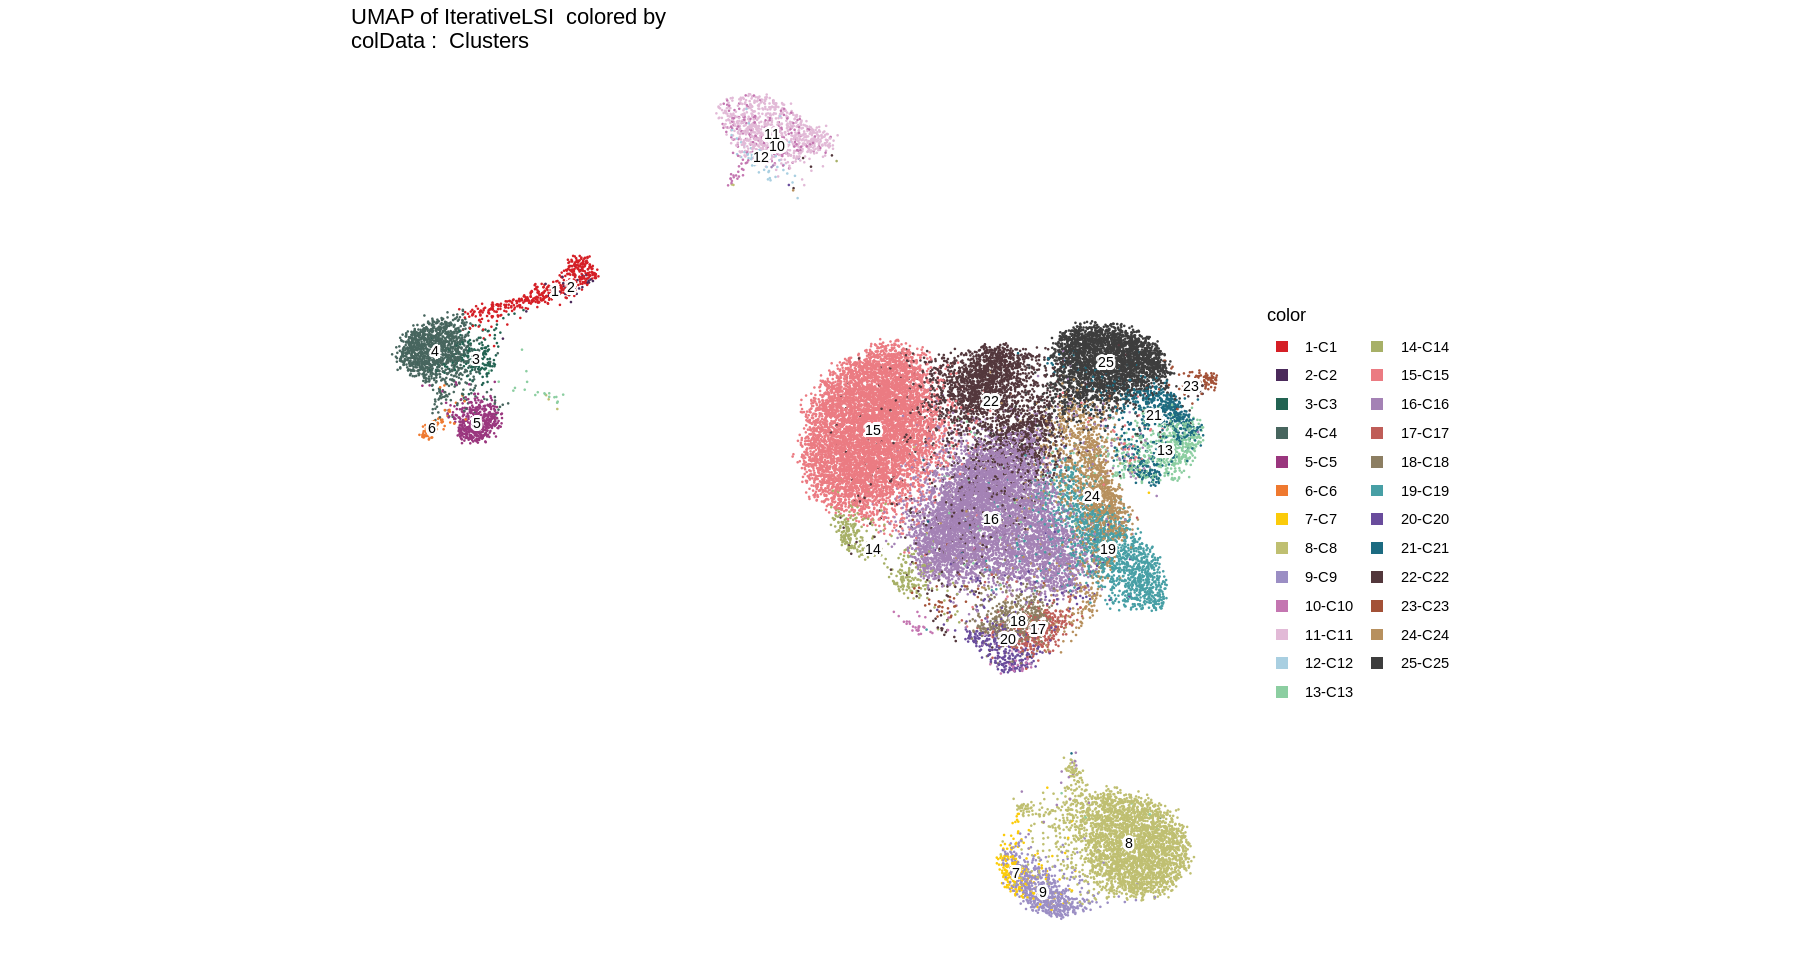

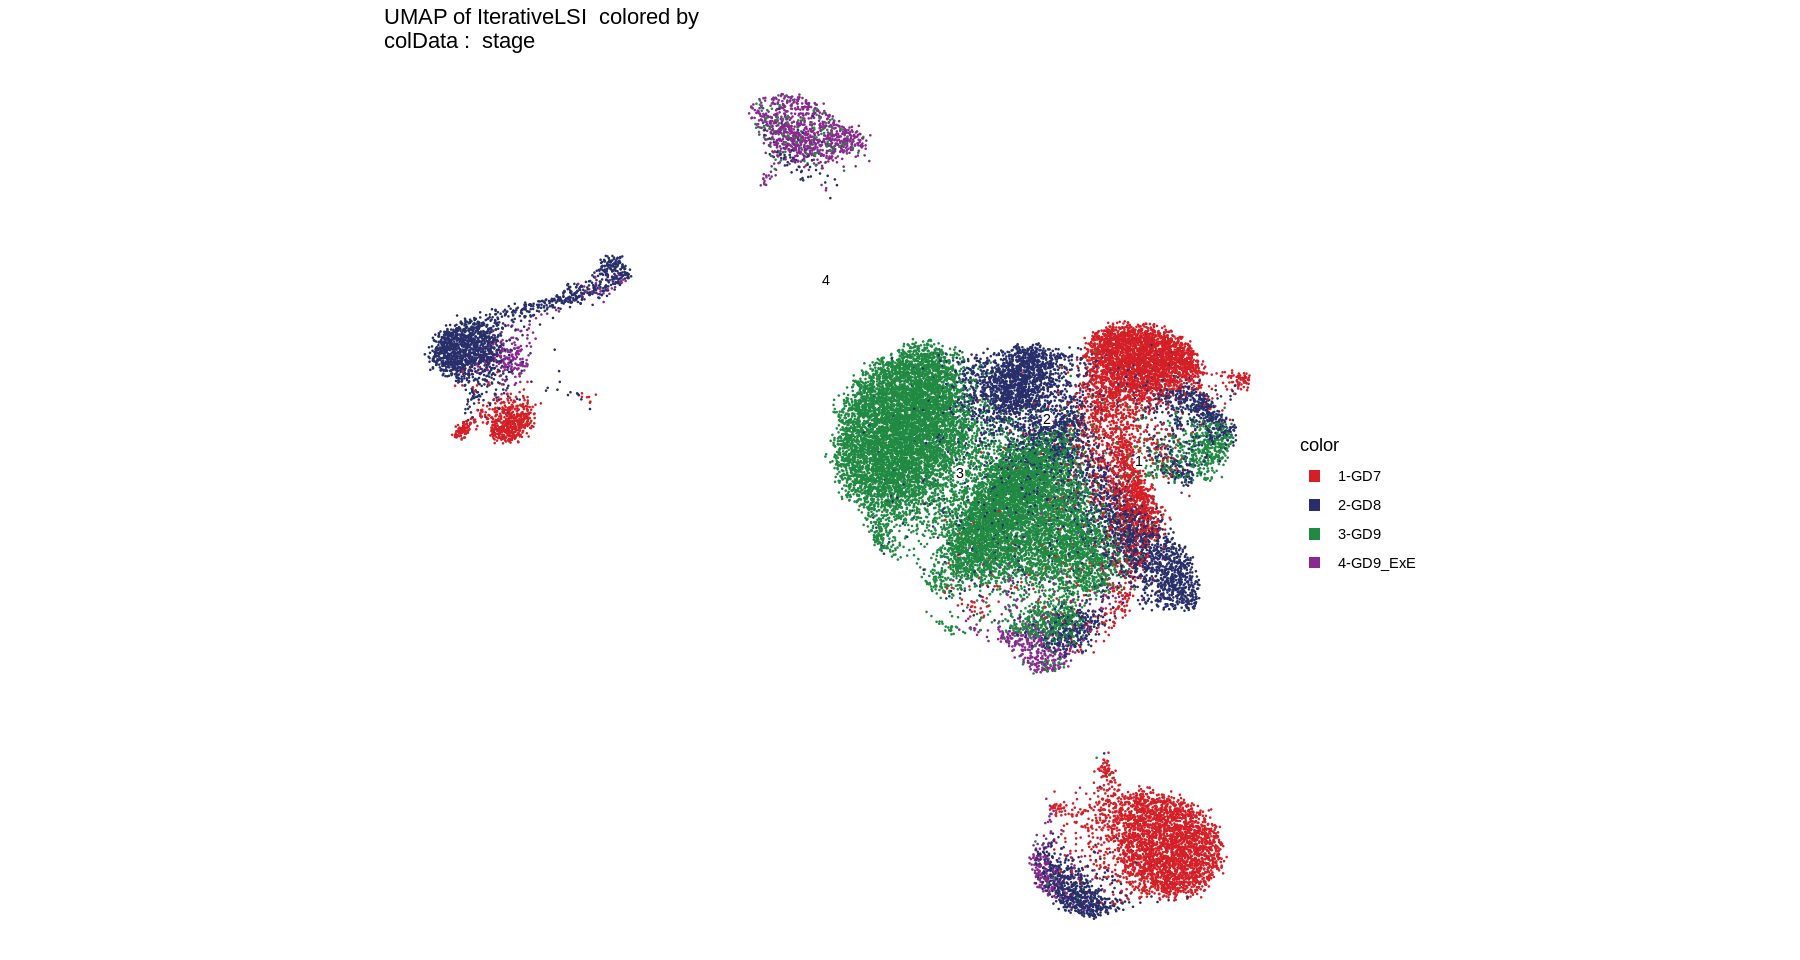

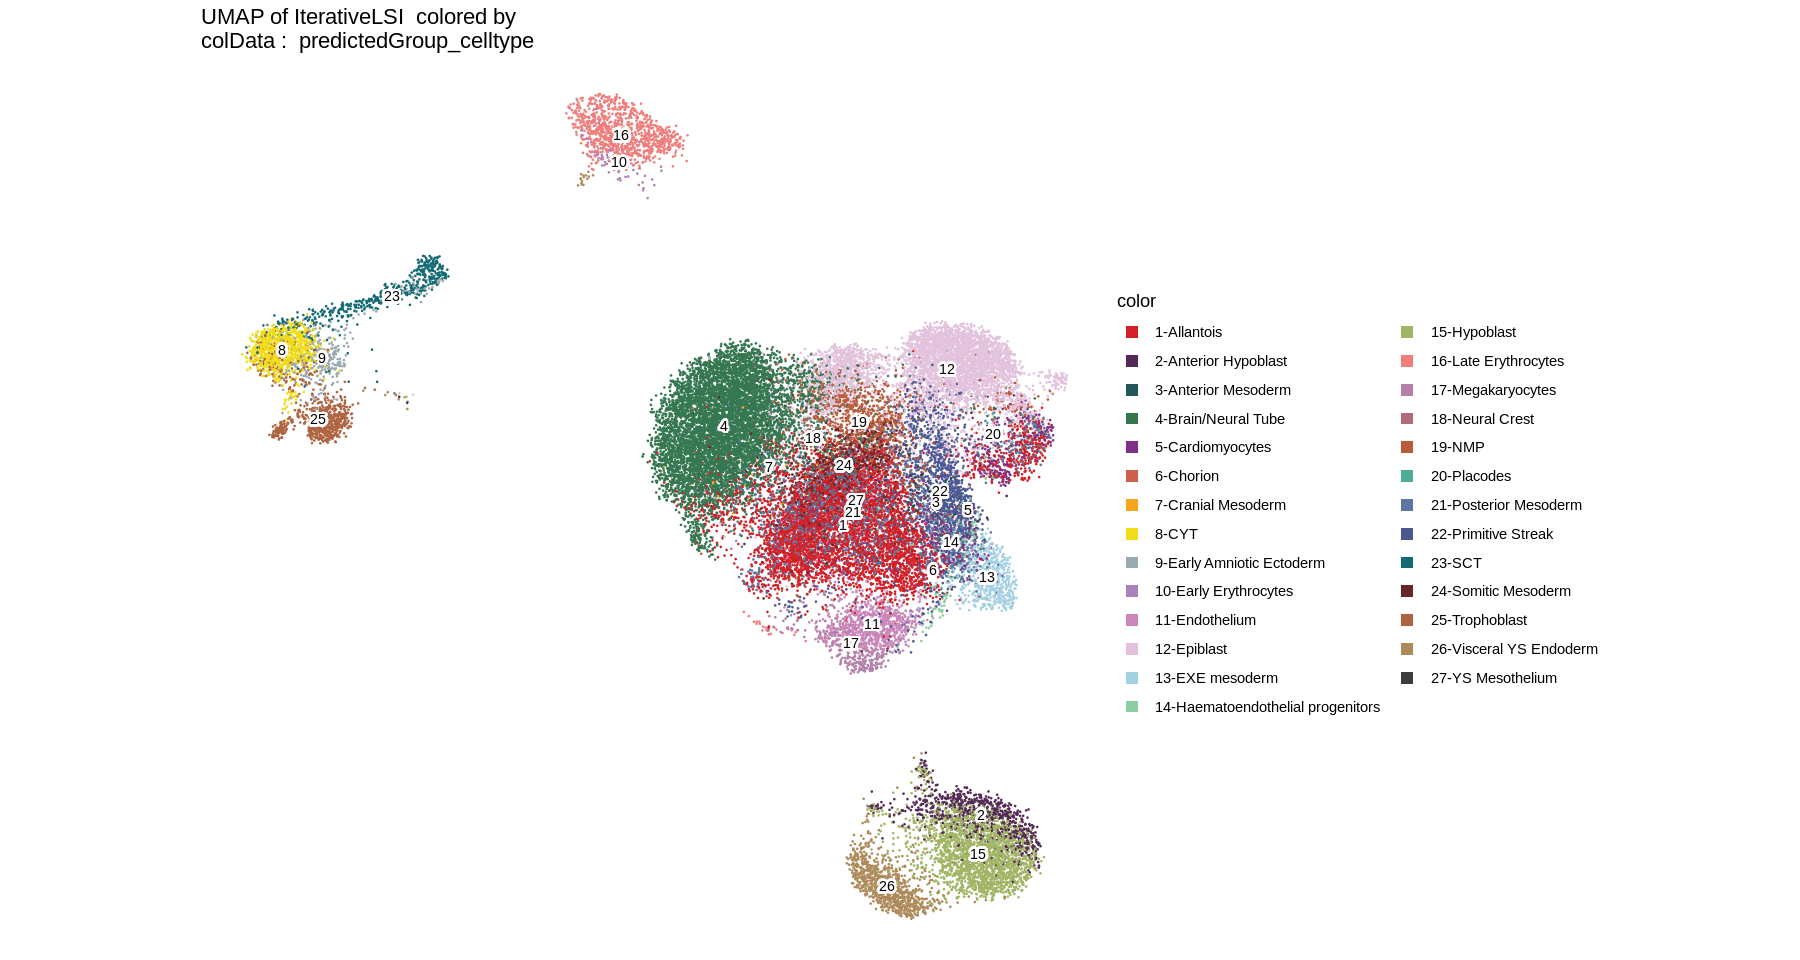

In [6]:
p1
p2 
p3

In [10]:
umap = getEmbedding(ArchRProject.filt)
colnames(umap) = c('umap1', 'umap2')
umap = as.data.frame(merge(umap,ArchRProject.filt@cellColData, by = 0))

In [18]:
stage_colours = c("GD7" = "#D56958",
                  'GD8' = '#6EC280',
                  'GD9' = '#6494D8',
                  'GD9_ExE' = '#BEB44D')

png 
  2

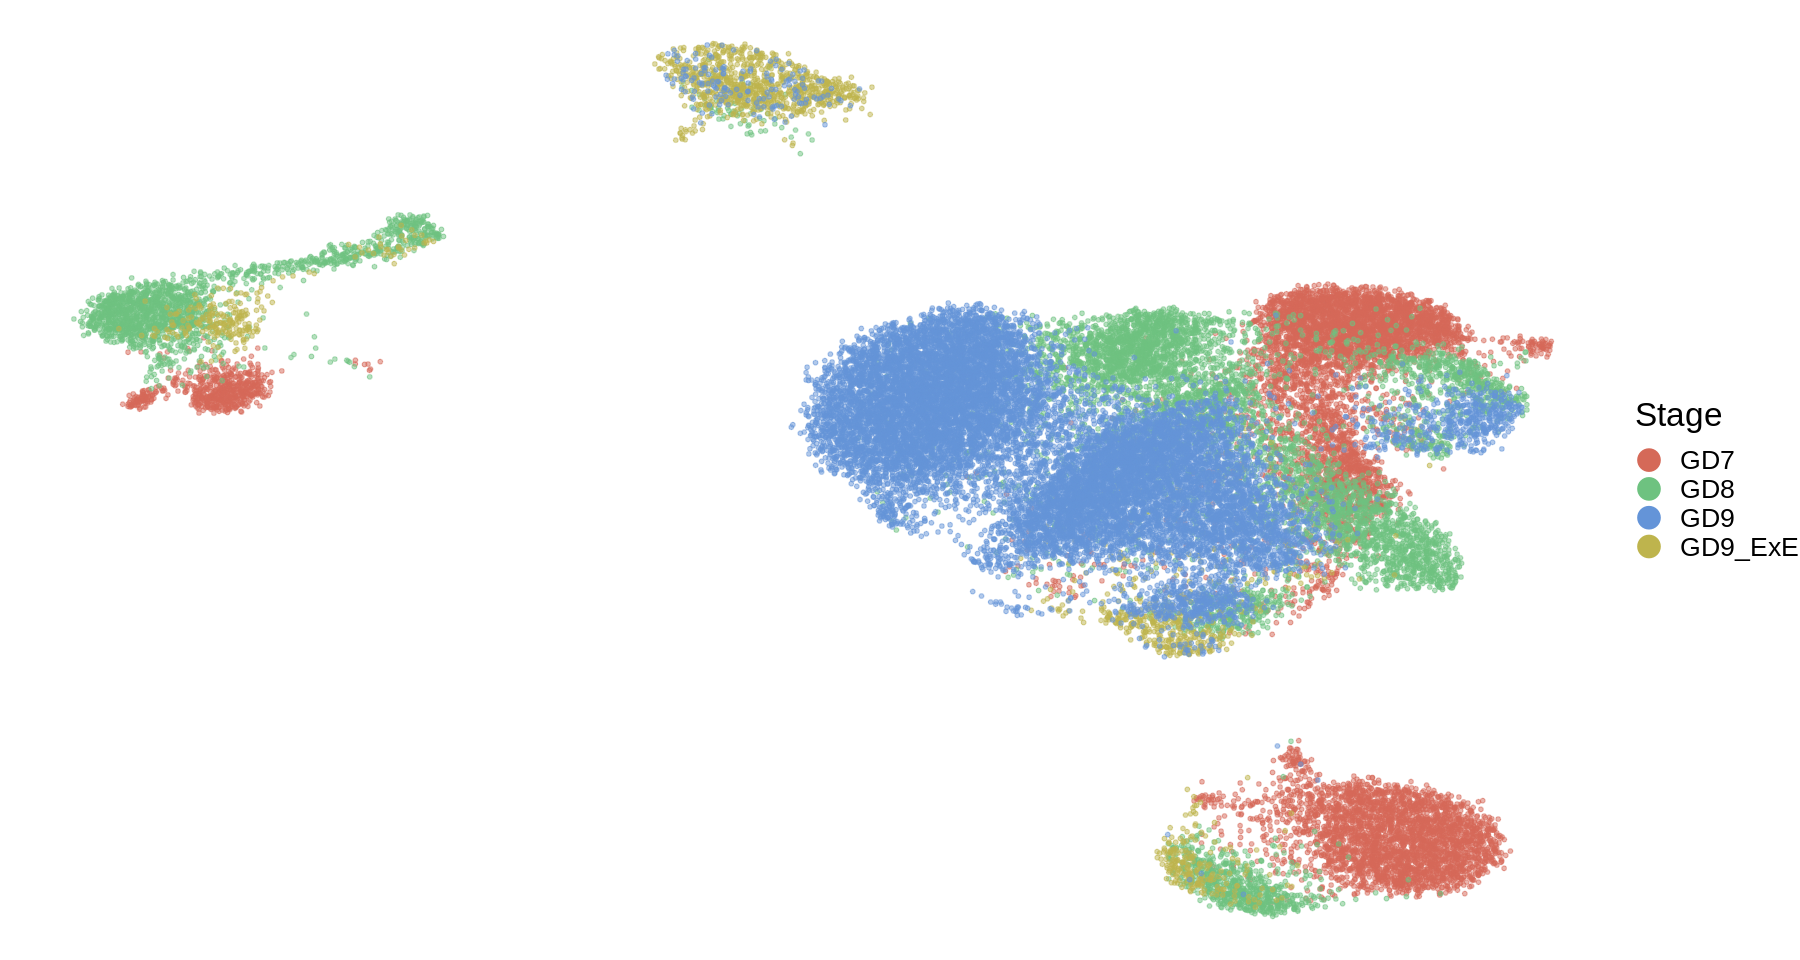

In [32]:
stage.plot = ggplot(umap, aes(umap1, umap2, col=stage)) + 
                geom_point(size = 1, alpha = 0.5) +
                scale_colour_manual(values = stage_colours, name = "Stage") +
                guides(colour = guide_legend(override.aes = list(size=6, alpha=1))) +
                theme_void() + theme(text=element_text(size=20))
stage.plot

pdf(file = file.path(io$plot.dir, 'stage.pdf'), width = 10, height = 10) 
    stage.plot
dev.off()

png 
  2

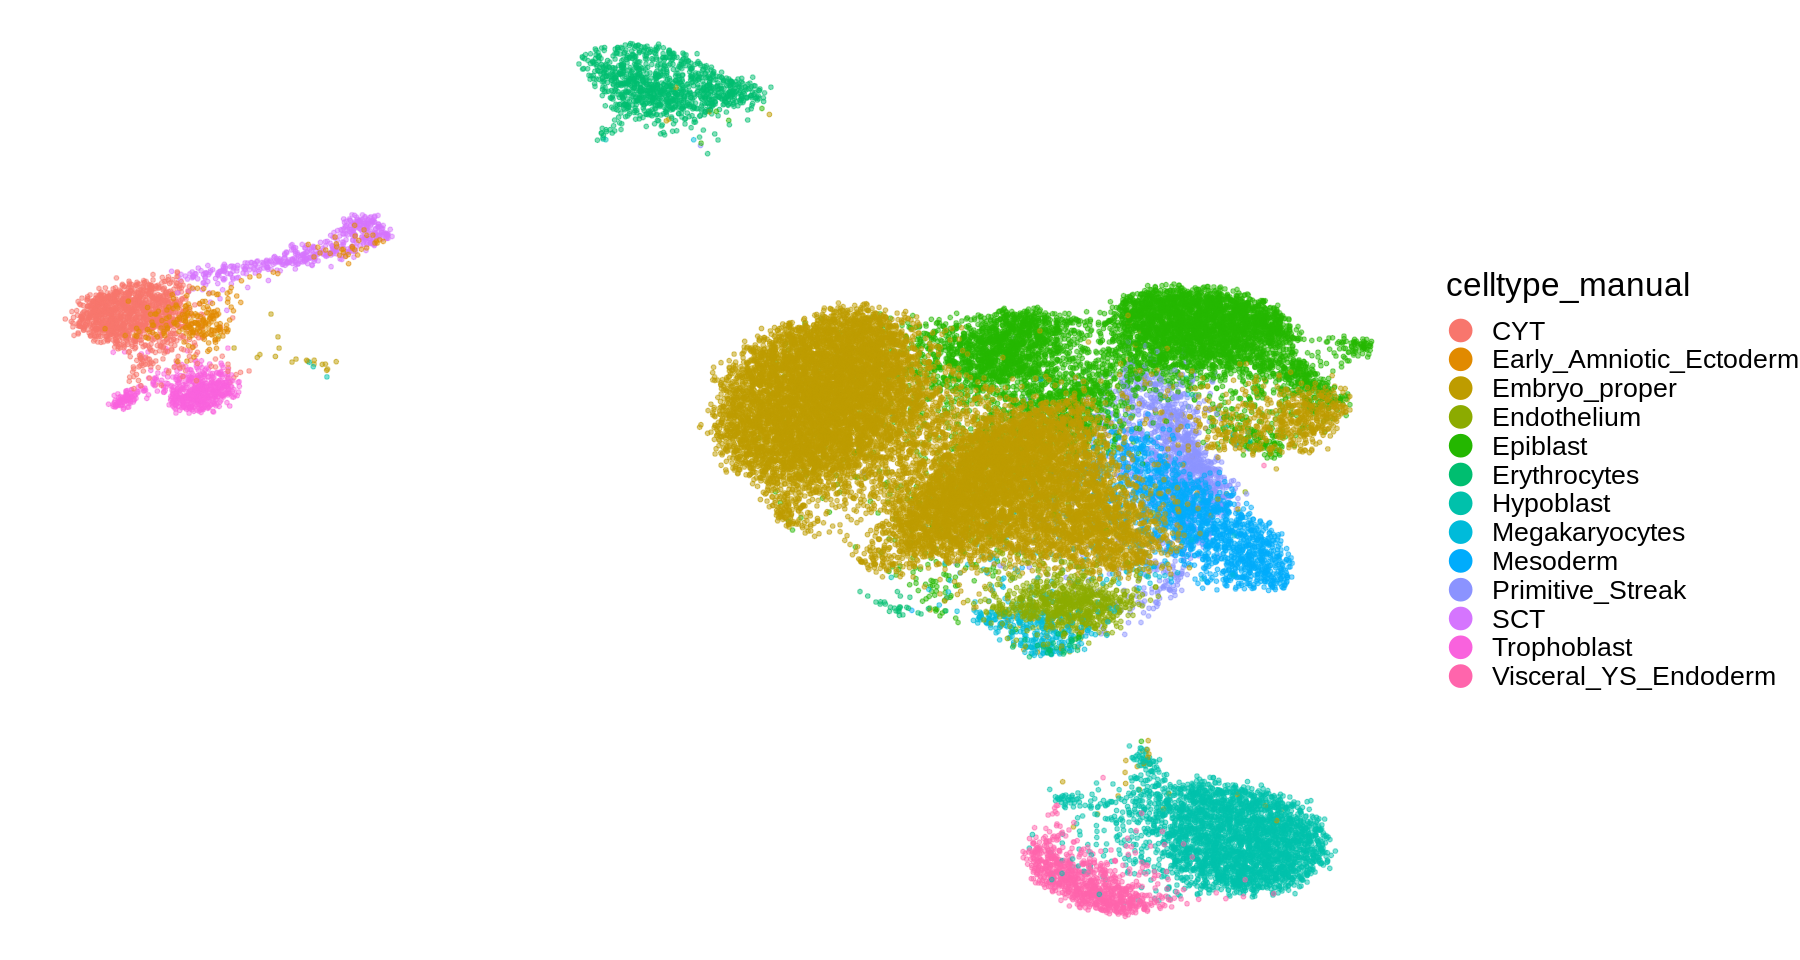

In [33]:
stage.plot = ggplot(umap, aes(umap1, umap2, col=celltype_manual)) + 
                geom_point(size = 1, alpha = 0.5) +
             #   scale_colour_manual(values = stage_colours, name = "Stage") +
                guides(colour = guide_legend(override.aes = list(size=6, alpha=1))) +
                theme_void() + theme(text=element_text(size=20))
stage.plot

pdf(file = file.path(io$plot.dir, 'celltype_manual.pdf'), width = 10, height = 10) 
    stage.plot
dev.off()

png 
  2

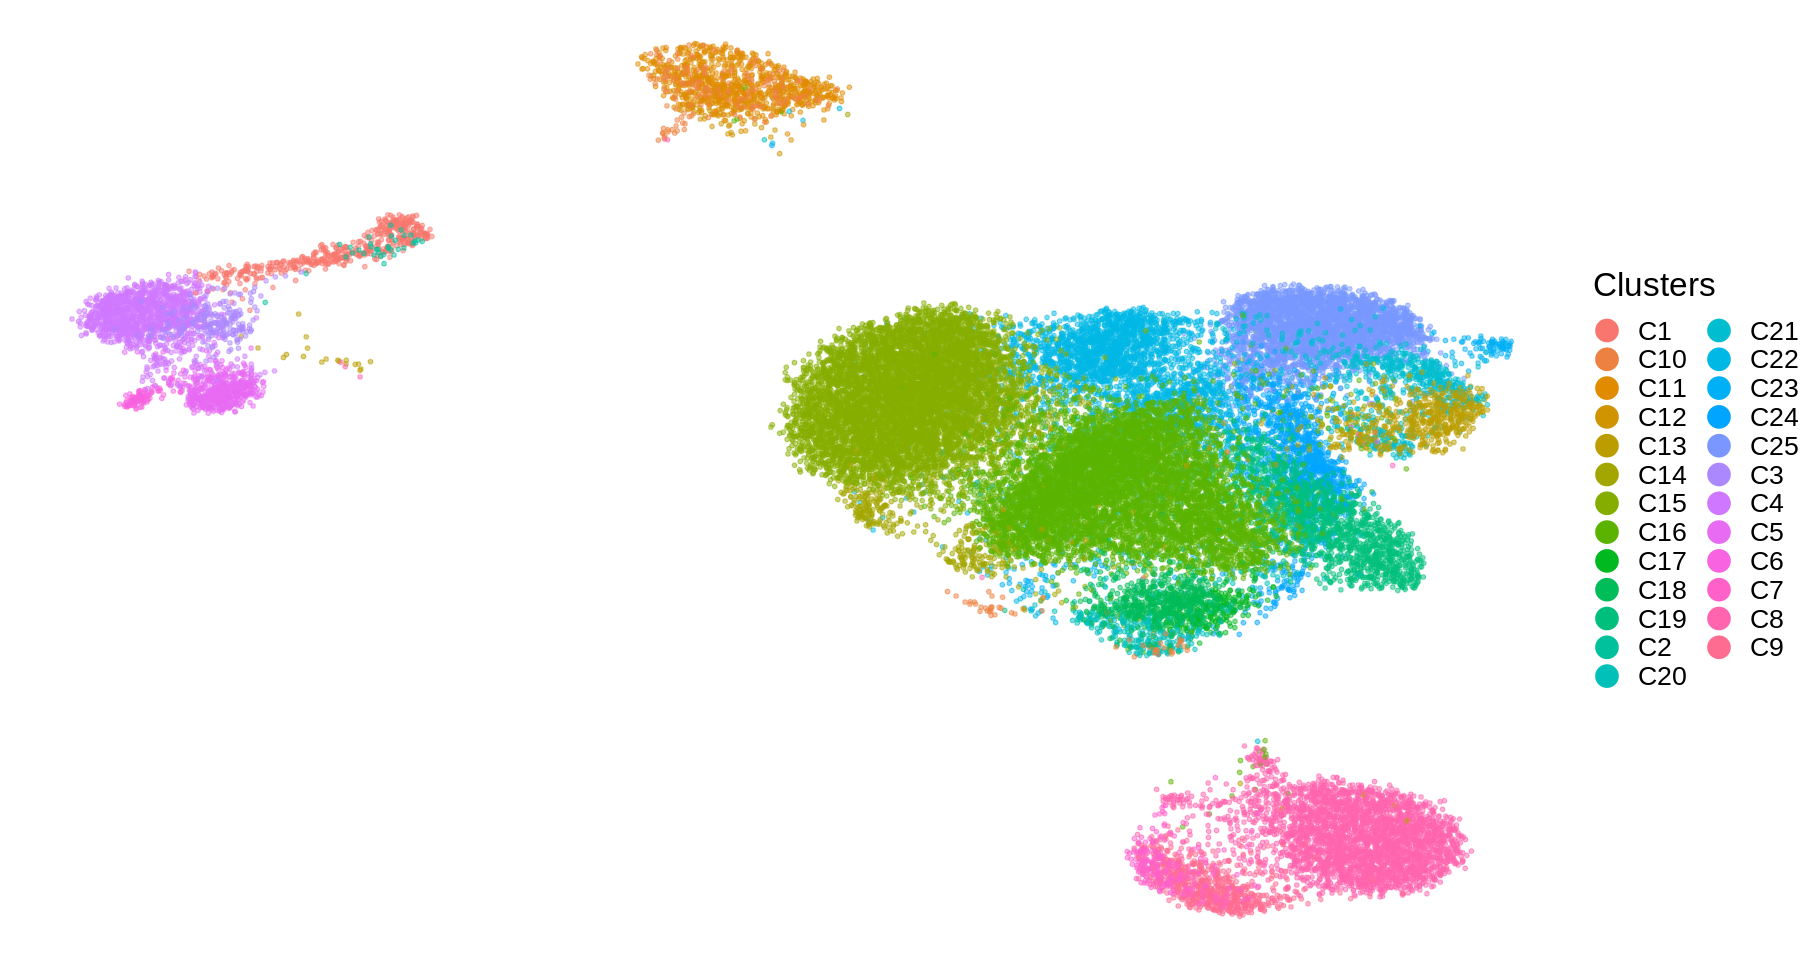

In [34]:
stage.plot = ggplot(umap, aes(umap1, umap2, col=Clusters)) + 
                geom_point(size = 1, alpha = 0.5) +
             #   scale_colour_manual(values = stage_colours, name = "Stage") +
                guides(colour = guide_legend(override.aes = list(size=6, alpha=1))) +
                theme_void() + theme(text=element_text(size=20))
stage.plot

pdf(file = file.path(io$plot.dir, 'Clusters.pdf'), width = 10, height = 10) 
    stage.plot
dev.off()

png 
  2

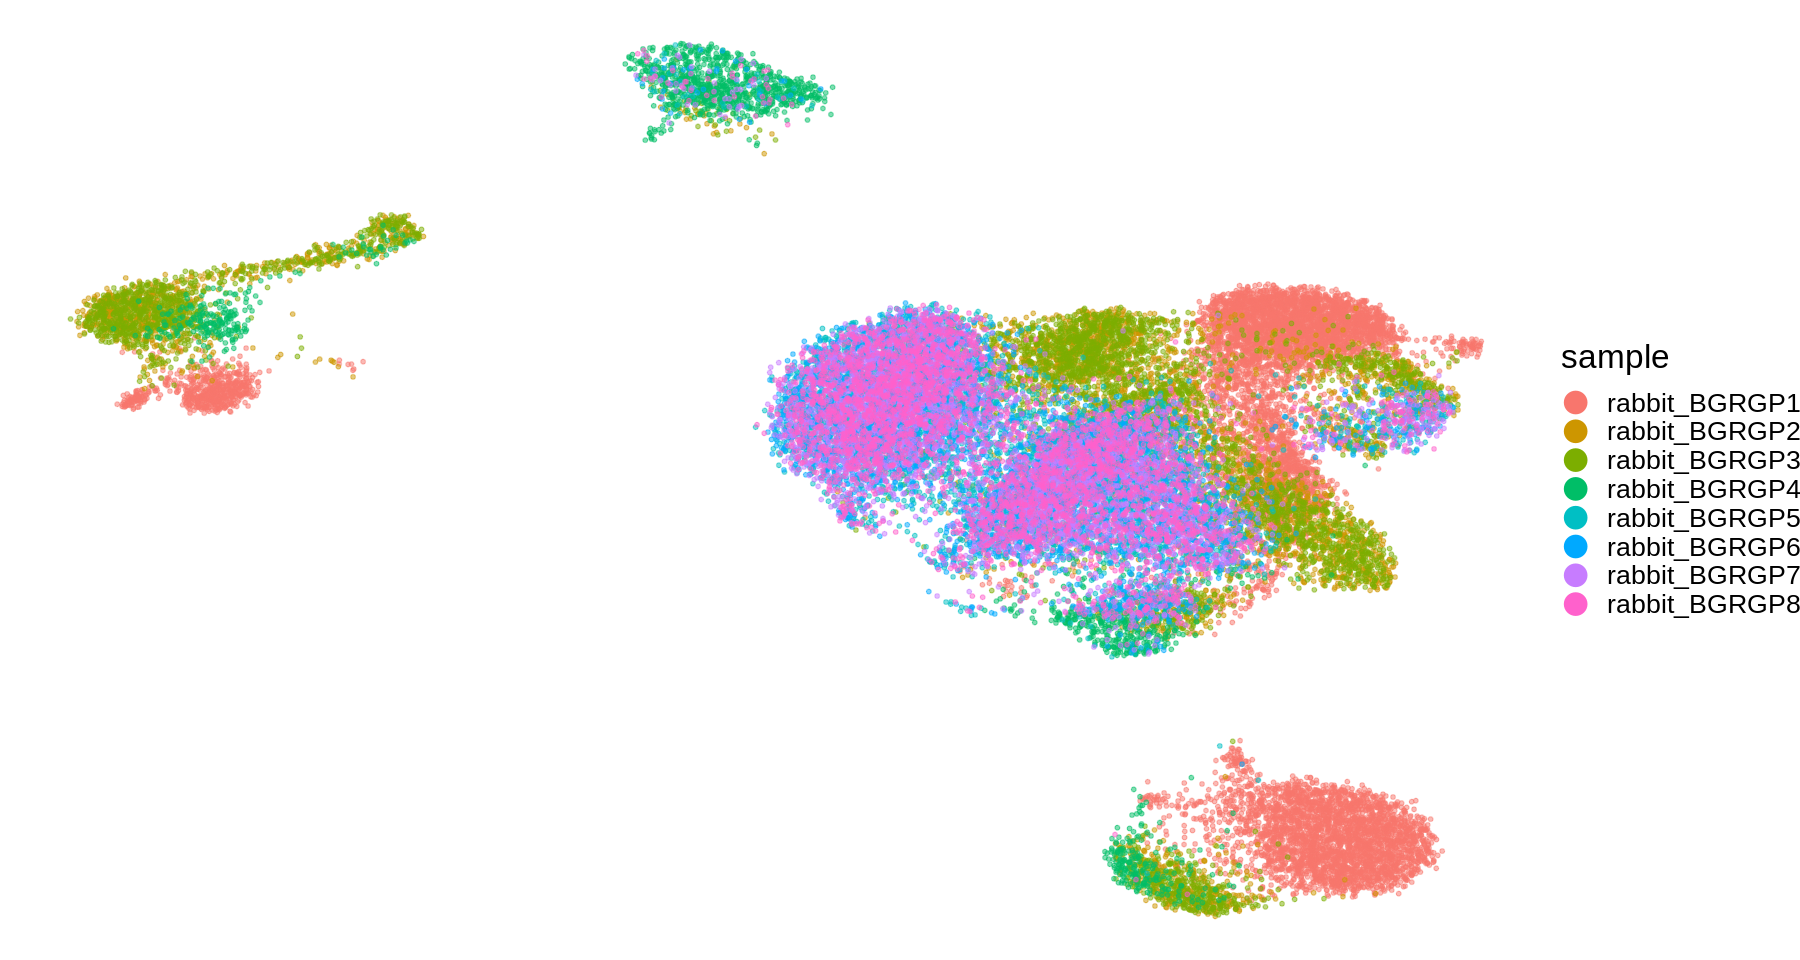

In [36]:
stage.plot = ggplot(umap, aes(umap1, umap2, col=sample)) + 
                geom_point(size = 1, alpha = 0.5) +
             #   scale_colour_manual(values = stage_colours, name = "Stage") +
                guides(colour = guide_legend(override.aes = list(size=6, alpha=1))) +
                theme_void() + theme(text=element_text(size=20))
stage.plot

pdf(file = file.path(io$plot.dir, 'sample.pdf'), width = 10, height = 10) 
    stage.plot
dev.off()

### Heatmaps

#### Tiles

In [ ]:
# Tiles
markersTile <- getMarkerFeatures(
    ArchRProj = ArchRProject.filt, 
    useMatrix = "TileMatrix", 
    groupBy = "predictedGroup_celltype",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-366f1108eab47-Date-2021-12-07_Time-09-47-02.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Binary.Matrix

2021-12-07 09:47:09 : Matching Known Biases, 0.065 mins elapsed.

2021-12-07 09:47:31 : Computing Pairwise Tests (1 of 25), 0.429 mins elapsed.

Pairwise Test C1 : Seqnames chr1

Pairwise Test C1 : Seqnames chr10

Pairwise Test C1 : Seqnames chr11

Pairwise Test C1 : Seqnames chr12

Pairwise Test C1 : Seqnames chr13

Pairwise Test C1 : Seqnames chr14

Pairwise Test C1 : Seqnames chr15

Pairwise Test C1 : Seqnames chr16

Pairwise Test C1 : Seqnames chr17

Pairwise Test C1 : Seqnames chr18

Pairwise Test C1 : Seqnames chr19

Pairwise Test C1 : Seqnames chr2

Pairwise Test C1 : Seqnames chr20

Pairwise Test C1 : Seqnames chr21

Pairwise Test C1 : Seqnames chr3

Pairwise Test C1 : Seqnames chr4

Pairwise Test C1 : Seqnames chr5

Pairwise Test C1 : Seqnames chr6

Pairwise Test C1 : Seqnames chr7


In [ ]:
saveRDS(markersTile, file.path(io$markers, 'markersTile.rds'))

In [ ]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersTile, 
  cutOff = "FDR <= 0.01 & Log2FC >= 1.25", 
  transpose = TRUE
)

In [ ]:
options(repr.plot.width=15, repr.plot.height=8)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [ ]:
plotPDF(heatmapGS, name = "Tile-Marker-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

#### Gene Scores

In [5]:
ArchRProject.filt@cellColData = ArchRProject.filt@cellColData[,1:23]

In [6]:
# Gene scores
markersGS <- getMarkerFeatures(
    ArchRProj = ArchRProject.filt, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-3a99d1d64a9fc-Date-2021-12-07_Time-16-53-28.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2021-12-07 16:53:29 : Matching Known Biases, 0.002 mins elapsed.

2021-12-07 16:53:42 : Computing Pairwise Tests (1 of 25), 0.222 mins elapsed.

Pairwise Test C1 : Seqnames chr1

Pairwise Test C1 : Seqnames chr10

Pairwise Test C1 : Seqnames chr11

Pairwise Test C1 : Seqnames chr12

Pairwise Test C1 : Seqnames chr13

Pairwise Test C1 : Seqnames chr14

Pairwise Test C1 : Seqnames chr15

Pairwise Test C1 : Seqnames chr16

Pairwise Test C1 : Seqnames chr17

Pairwise Test C1 : Seqnames chr18

Pairwise Test C1 : Seqnames chr19

Pairwise Test C1 : Seqnames chr2

Pairwise Test C1 : Seqnames chr20

Pairwise Test C1 : Seqnames chr21

Pairwise Test C1 : Seqnames chr3

Pairwise Test C1 : Seqnames chr4

Pairwise Test C1 : Seqnames chr5

Pairwise Test C1 : Seqnames chr6

Pairwise Test C1 : Seqnames chr7


Pairwise Test C10 : Seqnames chr18

Pairwise Test C10 : Seqnames chr19

Pairwise Test C10 : Seqnames chr2

Pairwise Test C10 : Seqnames chr20

Pairwise Test C10 : Seqnames chr21

Pairwise Test C10 : Seqnames chr3

Pairwise Test C10 : Seqnames chr4

Pairwise Test C10 : Seqnames chr5

Pairwise Test C10 : Seqnames chr6

Pairwise Test C10 : Seqnames chr7

Pairwise Test C10 : Seqnames chr8

Pairwise Test C10 : Seqnames chr9

Pairwise Test C10 : Seqnames chrX

2021-12-07 17:00:18 : Computing Pairwise Tests (11 of 25), 6.821 mins elapsed.

Pairwise Test C11 : Seqnames chr1

Pairwise Test C11 : Seqnames chr10

Pairwise Test C11 : Seqnames chr11

Pairwise Test C11 : Seqnames chr12

Pairwise Test C11 : Seqnames chr13

Pairwise Test C11 : Seqnames chr14

Pairwise Test C11 : Seqnames chr15

Pairwise Test C11 : Seqnames chr16

Pairwise Test C11 : Seqnames chr17

Pairwise Test C11 : Seqnames chr18

Pairwise Test C11 : Seqnames chr19

Pairwise Test C11 : Seqnames chr2

Pairwise Test C11 : Seqnames ch

2021-12-07 17:06:12 : Computing Pairwise Tests (20 of 25), 12.726 mins elapsed.

Pairwise Test C20 : Seqnames chr1

Pairwise Test C20 : Seqnames chr10

Pairwise Test C20 : Seqnames chr11

Pairwise Test C20 : Seqnames chr12

Pairwise Test C20 : Seqnames chr13

Pairwise Test C20 : Seqnames chr14

Pairwise Test C20 : Seqnames chr15

Pairwise Test C20 : Seqnames chr16

Pairwise Test C20 : Seqnames chr17

Pairwise Test C20 : Seqnames chr18

Pairwise Test C20 : Seqnames chr19

Pairwise Test C20 : Seqnames chr2

Pairwise Test C20 : Seqnames chr20

Pairwise Test C20 : Seqnames chr21

Pairwise Test C20 : Seqnames chr3

Pairwise Test C20 : Seqnames chr4

Pairwise Test C20 : Seqnames chr5

Pairwise Test C20 : Seqnames chr6

Pairwise Test C20 : Seqnames chr7

Pairwise Test C20 : Seqnames chr8

Pairwise Test C20 : Seqnames chr9

Pairwise Test C20 : Seqnames chrX

2021-12-07 17:06:50 : Computing Pairwise Tests (21 of 25), 13.353 mins elapsed.

Pairwise Test C21 : Seqnames chr1

Pairwise Test C21 : S

In [7]:
saveRDS(markersGS, file.path(io$markers, 'markersGS.rds'))

In [26]:
markersGS = readRDS(file.path(io$markers, 'markersGS.rds'))

In [37]:
exons = gene_map[match(markersGS@elementMetadata$name, gene_map$gene_id),][, 1]
markersGS@elementMetadata$name = exons

In [38]:
markerList <- getMarkers(markersGS, cutOff = "FDR <= 0.01 & Log2FC >= 1.25")

In [41]:
label = lapply(names(markerList), function(x){
    Topmarkers = head(markerList[[x]][order(-markerList[[x]]$Log2FC),], 2)
    Topmarkers = paste0(Topmarkers$seqnames, ':', Topmarkers$name)
})
labels = unlist(label)

In [42]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersGS, 
  cutOff = "FDR <= 0.01 & Log2FC >= 1.25", 
  labelMarkers = labels,
  transpose = TRUE
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-3a99d65744018-Date-2021-12-07_Time-17-24-12.log
If there is an issue, please report to github with logFile!

Printing Top Marker Genes:

C1:

	chr1:SUSD1, chr1:ENSOCUG00000021292, chr1:ENSOCUG00000025587, chr1:ENSOCUG00000010170, chr1:ENSOCUG00000029032, chr1:ENSOCUG00000017040, chr1:ENSOCUG00000030096, chr1:ENSOCUG00000000531, chr1:ENSOCUG00000000822, chr1:ENSOCUG00000027428, chr1:ENSOCUG00000017854, chr1:ENSOCUG00000029172, chr1:ENSOCUG00000033081, chr1:ENSOCUG00000037212, chr1:ENSOCUG00000036518

C2:

	chr1:PLIN2, chr1:GNAQ, chr11:ENSOCUG00000010243, chr13:MACF1, chr17:MYO1E, chr2:NCK2, chr2:ENSOCUG00000010225, chrX:GPR174, chr1:ENSOCUG00000029370, chr1:DAPK1, chr14:ENSOCUG00000030521, chr14:SLC49A4, chr18:RHOBTB1, chr2:ENSOCUG00000037837, chr2:MTUS1

C3:

	chr1:ZNF215, chr1:MUC15, chr11:ENSOCUG00000035171, chr13:ENSOCUG00000023499, chr13:ENSOCUG00000028209, chr13:SCP2, chr13:ENSOCUG00000003171, chr13:ENSOCUG00000022473, chr13:ENS

 [1] "chr1:ENSOCUG00000017854"  "chr13:ENSOCUG00000019557"
 [3] "chr2:ENSOCUG00000010225"  "chr2:ENSOCUG00000036681" 
 [5] "chr19:RNF222"             "chr7:ENSOCUG00000034946" 
 [7] "chr6:ENSOCUG00000030566"  "chr13:ENSOCUG00000027503"
 [9] "chr1:ENSOCUG00000034626"  "chr2:ENSOCUG00000028460" 
[11] "chr19:OR4D2"              "chr3:ENSOCUG00000039547" 
[13] "chr15:AFP"                "chr12:ENSOCUG00000023234"
[15] "chrX:ENSOCUG00000032710"  "chr1:ENSOCUG00000027365" 
[17] "chr1:APOA4"               "chr1:ENSOCUG00000027365" 
[19] "chr1:ENSOCUG00000039498"  "chr1:GLNB2"              
[21] "chr1:ENSOCUG00000039498"  "chr1:GLNB2"              
[23] "chr1:GLNB2"               "chr1:ENSOCUG00000039498" 
[25] "chr8:ENSOCUG00000024665"  "chr12:ENSOCUG00000023168"
[27] "chr19:OR1P1"              "chr13:ENSOCUG00000030332"
[29] "chr20:FAM181A"            "chr5:ENSOCUG00000035771" 
[31] "chr1:ENSOCUG00000033576"  "chr1:ENSOCUG00000037640" 
[33] "chr1:FLI1"                "chr5:ENSOCUG00000038241

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-3a99d65744018-Date-2021-12-07_Time-17-24-12.log



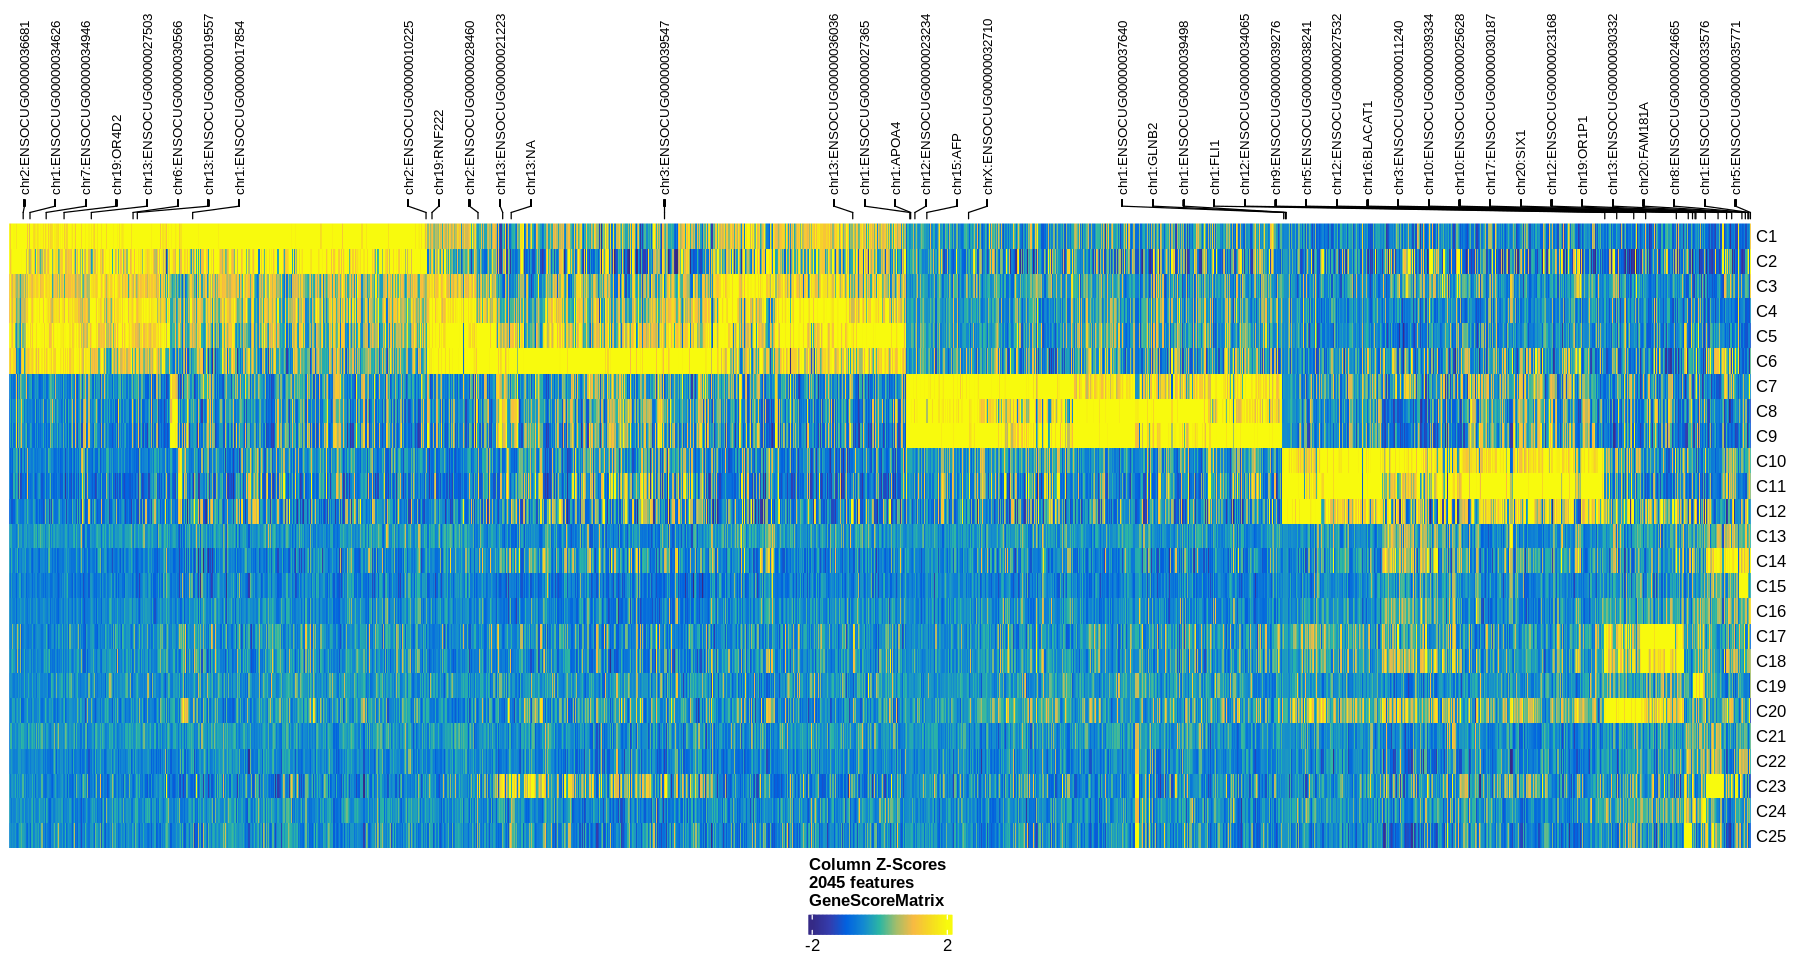

In [43]:
options(repr.plot.width=15, repr.plot.height=8)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [44]:
plotPDF(heatmapGS, name = "GeneScores-Marker-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

Plotting ComplexHeatmap!



#### Peaks

In [36]:
# Peaks
markersPeaks = readRDS(file.path(io$output.directory, 'Motifs/markersPeaks.rds'))

In [169]:
saveRDS(markersPeaks, file.path(io$markers, 'markersPeaks.rds'))

In [174]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersPeaks, 
  cutOff = "FDR <= 0.01 & Log2FC >= 1.25", 
  transpose = TRUE
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-2e6ba4cdb078c-Date-2021-12-06_Time-21-51-33.log
If there is an issue, please report to github with logFile!

Identified 167682 markers!



 [1] "chr1:ENSOCUG00000017854"  "chr2:ENSOCUG00000010225" 
 [3] "chr19:RNF222"             "chr6:ENSOCUG00000030566" 
 [5] "chr1:ENSOCUG00000034626"  "chr19:OR4D2"             
 [7] "chr15:AFP"                "chrX:ENSOCUG00000032710" 
 [9] "chr1:APOA4"               "chr1:ENSOCUG00000039498" 
[11] "chr1:ENSOCUG00000039498"  "chr1:GLNB2"              
[13] "chr8:ENSOCUG00000024665"  "chr12:ENSOCUG00000023168"
[15] "chr13:ENSOCUG00000030332" "chr5:ENSOCUG00000035771" 
[17] "chr1:ENSOCUG00000037640"  "chr5:ENSOCUG00000038241" 
[19] "chr10:ENSOCUG00000025628" "chr9:ENSOCUG00000039276" 
[21] ":"                        "chr3:ENSOCUG00000011240" 
[23] "chr13:U1"                 "chr17:ENSOCUG00000030187"
[25] "chr13:ENSOCUG00000036036"


Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-2e6ba4cdb078c-Date-2021-12-06_Time-21-51-33.log



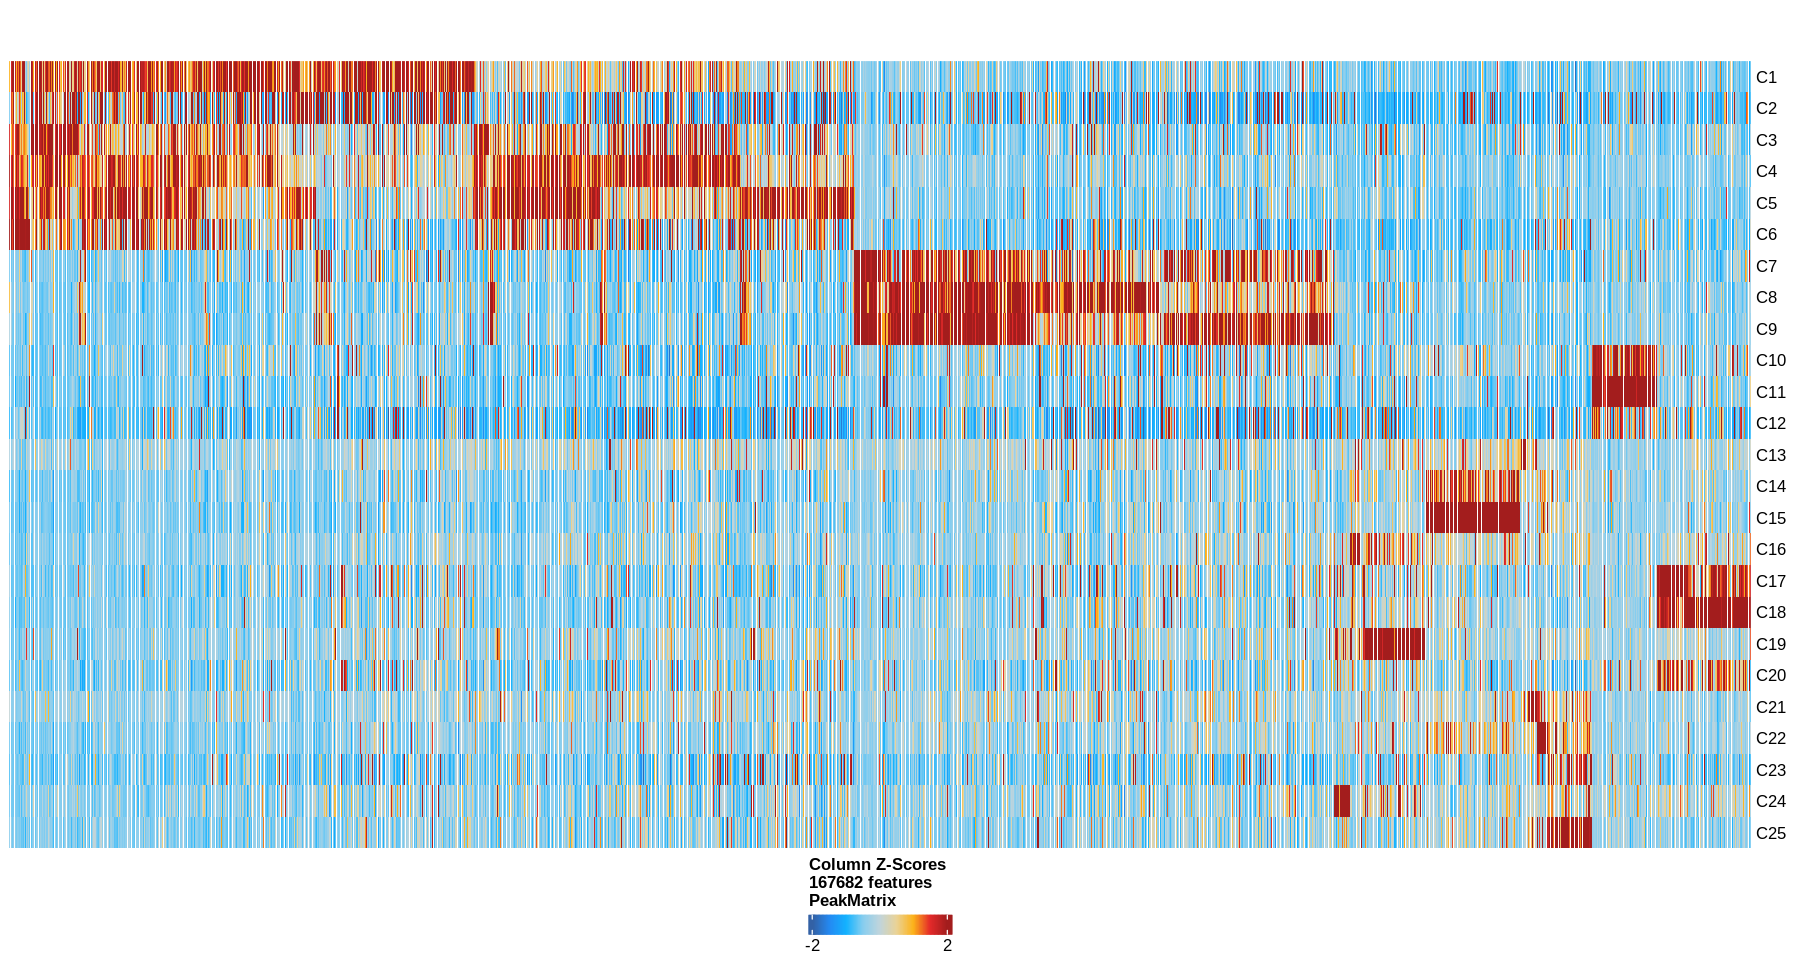

In [175]:
options(repr.plot.width=15, repr.plot.height=8)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [177]:
plotPDF(heatmapGS, name = "Peaks-Marker-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

Plotting ComplexHeatmap!



#### Motifs enrichment

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-1c5ec132678d4-Date-2021-12-12_Time-20-35-38.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

Plotting ComplexHeatmap!



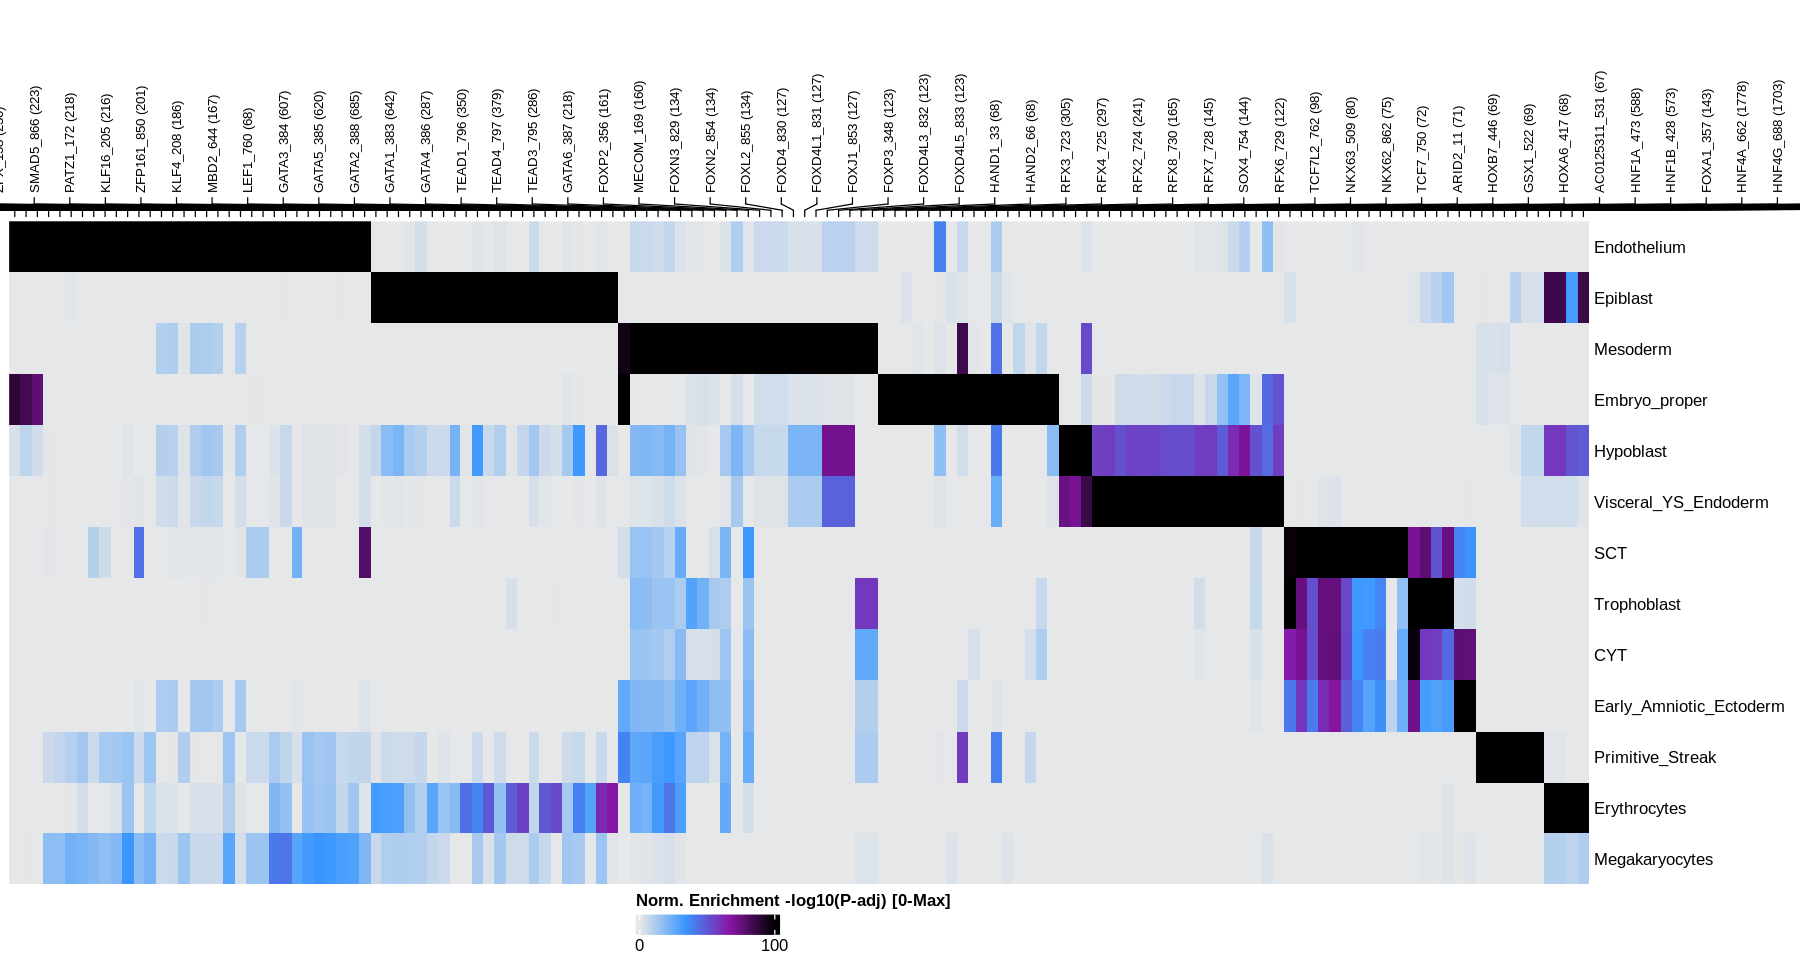

In [7]:
enrichMotifs = readRDS(file.path(io$output.directory, 'Motifs/enrichMotifs_up.rds'))
heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = 20, transpose = TRUE)
ComplexHeatmap::draw(heatmapEM, heatmap_legend_side = "bot", annotation_legend_side = "bot")
plotPDF(heatmapEM, name = "MotifsUp-Marker-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2e6ba5a55867c-Date-2021-12-06_Time-21-59-50.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

Plotting ComplexHeatmap!



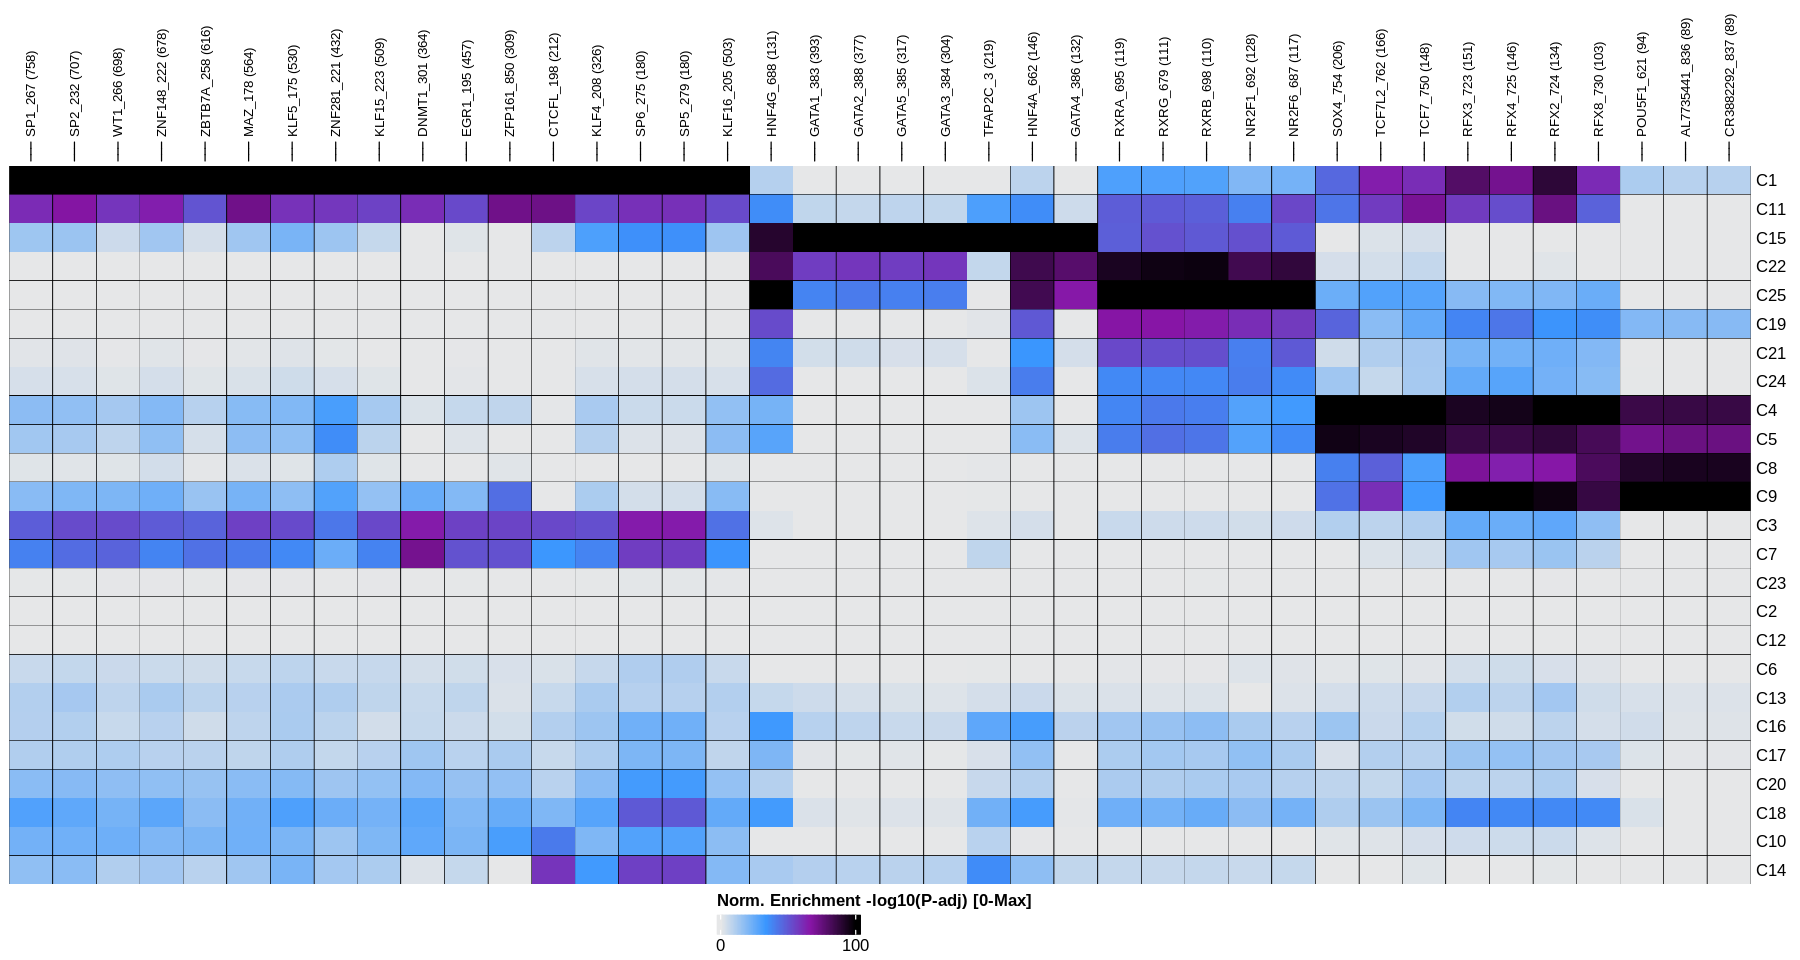

In [191]:
enrichMotifs = readRDS(file.path(io$output.directory, 'Motifs/enrichMotifs_down.rds'))
heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = 7, transpose = TRUE)
ComplexHeatmap::draw(heatmapEM, heatmap_legend_side = "bot", annotation_legend_side = "bot")
plotPDF(heatmapEM, name = "MotifsDown-Marker-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

#### Motif heatmap

In [11]:
# Motif heatmap
markersMM <- getMarkerFeatures(
    ArchRProj = ArchRProject.filt, 
    useMatrix = 'MotifMatrix', 
    groupBy = "celltype_manual",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon", 
     useSeqnames = 'z'
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1c5ec27028a3b-Date-2021-12-12_Time-20-38-12.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Assays.Matrix

2021-12-12 20:38:13 : Matching Known Biases, 0.001 mins elapsed.

2021-12-12 20:38:16 : Computing Pairwise Tests (1 of 13), 0.055 mins elapsed.

Pairwise Test CYT : Seqnames z

2021-12-12 20:38:18 : Computing Pairwise Tests (2 of 13), 0.091 mins elapsed.

Pairwise Test Early_Amniotic_Ectoderm : Seqnames z

2021-12-12 20:38:20 : Computing Pairwise Tests (3 of 13), 0.12 mins elapsed.

Pairwise Test Embryo_proper : Seqnames z

2021-12-12 20:38:22 : Computing Pairwise Tests (4 of 13), 0.152 mins elapsed.

Pairwise Test Endothelium : Seqnames z

2021-12-12 20:38:24 : Computing Pairwise Tests (5 of 13), 0.184 mins elapsed.

Pairwise Test Epiblast : Seqnames z

2021-12-12 20:38:26 : Computing Pairwise Tests (6 of 13), 0.217 mins elapsed.

Pairwise Test Erythrocytes : Seqnames z

2021-12-12 20:38:27

In [34]:
saveRDS(markersMM, file.path(io$markers, 'markersMM.rds'))

In [12]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersMM, 
  cutOff = "FDR <= 0.001 & Log2FC >= 7", 
  log2Norm = FALSE,
  transpose = TRUE
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-1c5ec1654ab02-Date-2021-12-12_Time-20-38-48.log
If there is an issue, please report to github with logFile!

Identified 128 markers!



 [1] "ARID3A_6"   "HMGA2_13"   "TFAP4_23"   "TFEC_27"    "BHLHE41_44"
 [6] "ARNTL_50"   "HEY2_54"    "MYC_55"     "USF1_60"    "MITF_91"   
[11] "NFE2L2_115" "ATF6_116"   "NFE2_119"   "ATF4_122"   "ZNF76_164" 


Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-1c5ec1654ab02-Date-2021-12-12_Time-20-38-48.log



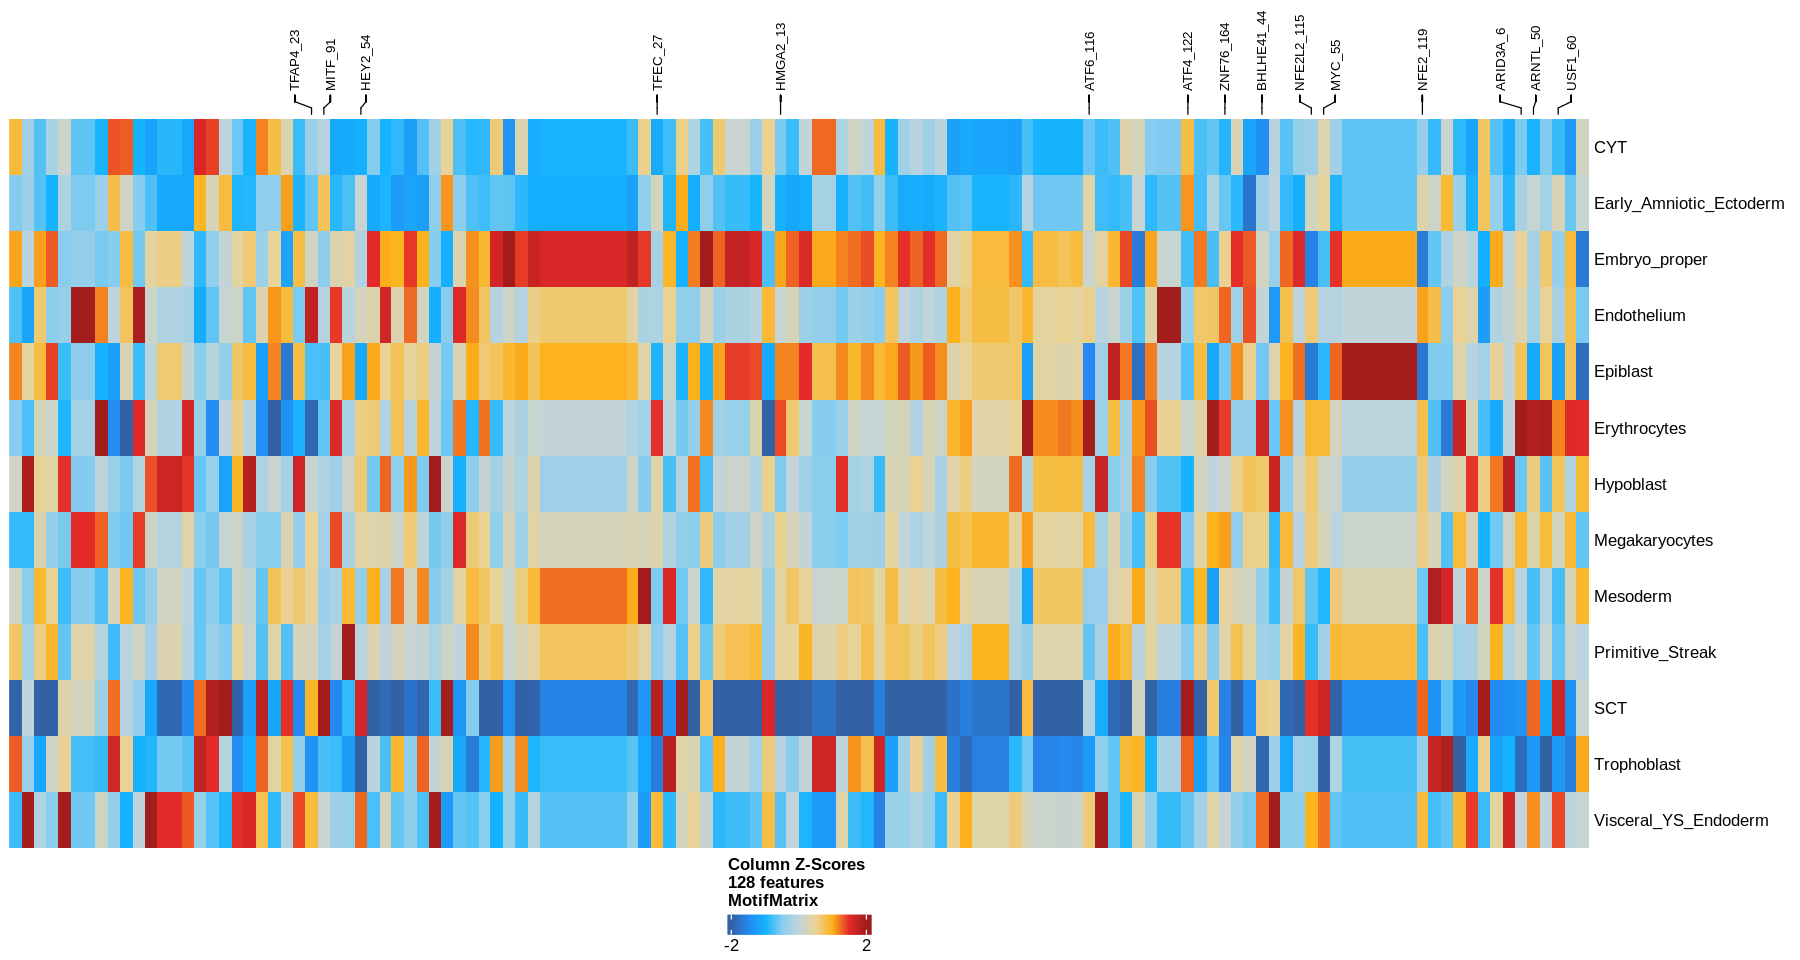

In [13]:
options(repr.plot.width=15, repr.plot.height=8)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [79]:
plotPDF(heatmapGS, name = "Motif-Marker-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

Plotting ComplexHeatmap!



### Plot specific genes

In [7]:
getAvailableMatrices(ArchRProject.filt)

[1] "GeneIntegrationMatrix" "GeneScoreMatrix"       "MotifMatrix"          
[4] "PeakMatrix"            "TileMatrix"

In [14]:
exons = gene_map[match(ArchRProject.filt@geneAnnotation$exons$gene_id, gene_map$gene_id),][, 2]
ArchRProject.filt@geneAnnotation$exons$symbol = exons

In [15]:
ArchRProject.filt@geneAnnotation$genes$symbol = ArchRProject.filt@geneAnnotation$genes$gene_id

In [22]:
plot_gene = function(gene){
 #   gene_name = gene_map[gene_map$ensembl_gene_id == gene, ]$external_gene_name
    gene_id = gene_map[gene_map$symbol == gene, ]$gene_id

    p1 = plotEmbedding(
        ArchRProj = ArchRProject.filt, 
        colorBy = "GeneScoreMatrix", 
        name = gene_id, 
        embedding = "UMAP",
        imputeWeights = getImputeWeights(ArchRProject.filt)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle(gene, 'Gene Accessibility')

    p2 = plotEmbedding(
        ArchRProj = ArchRProject.filt, 
        colorBy = "GeneIntegrationMatrix", 
        name = gene_id, 
        embedding = "UMAP",
        imputeWeights = getImputeWeights(ArchRProject.filt)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle('', 'Pseudo-Expression') 

    markerMotifs <- grep("z:", getFeatures(ArchRProject.filt, select = gene, useMatrix = "MotifMatrix"), value = TRUE)
    if(length(markerMotifs>0)){
       p3 = plotEmbedding(
        ArchRProj = ArchRProject.filt, 
        colorBy = "MotifMatrix", 
        name = markerMotifs, 
        embedding = "UMAP",
        imputeWeights = getImputeWeights(ArchRProject.filt)
        ) + 
        scale_fill_viridis() + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle('', 'Motif Accessibility')
    }
        
    
    gene_map = gene_map[match(ArchRProject.filt@geneAnnotation$genes$gene_id, gene_map$gene_id),]
    ArchRProject.filt@geneAnnotation$genes$symbol = gene_map$symbol
    p4 = plotBrowserTrack(
        ArchRProj = ArchRProject.filt, 
        groupBy = "celltype_manual", 
        geneSymbol = gene, 
        upstream = 40000,
        downstream = 40000,
       # useMatrix = 'GeneIntegrationMatrix',
        loops = getPeak2GeneLinks(ArchRProject.filt, resolution = 1000)
       # loops = getCoAccessibility(ArchRProject.filt, resolution = 10000)
    ) 
    ArchRProject.filt@geneAnnotation$genes$symbol = ArchRProject.filt@geneAnnotation$genes$gene_id

    if(length(markerMotifs>0)){
      umaps = ggarrange(p1, p2, p3, ncol = 3)
    }  else{umaps = ggarrange(p1, p2, ncol = 2)}
    track = ggarrange(p4[[1]])
   p = ggarrange(umaps, track, ncol=1, heights = c(5, 10))
   p
   
    outfile <- sprintf("%s/%s.pdf",io$plot.genes, gene)
    pdf(outfile, width=10, height=10)
        print(p)
    dev.off()
   
}

In [20]:
options(repr.plot.width=15, repr.plot.height=15)

In [23]:
#     'ENSOCUG00000017835', # DNMT3B > epiblast
#     'ENSOCUG00000025597', # GATA1 -> blood
#     'ENSOCUG00000009246', # GCM1 --> SCT 
#     'ENSOCUG00000026343', # VTCN1 --> amniotic ectoderm
#     'ENSOCUG00000000041', # NKX2-5 > heart
#     'ENSOCUG00000010829', # MYL4 > cardiomyocytes
#     'ENSOCUG00000015170', # HOXA11 > Allantois
#     'ENSOCUG00000017248', # TAL1
#     'ENSOCUG00000000451', # EOMES
#     'ENSOCUG00000002633', # OTX2 > neural
#     'ENSOCUG00000004752', # SIX6 > neural
#     'ENSOCUG00000014268', # Six1 > neural
#     'ENSOCUG00000005360', # Noto > Notochord
#     'ENSOCUG00000007084', # CHR > notochord
#     'ENSOCUG00000011487', # DKK1 > Gut/AVE
#     'ENSOCUG00000010192' # CDH5 > endothelium
genes = c('GATA1','DNMT3B','GCM1','VTCN1','NKX2-5','MYL4','HOXA11','TAL1','EOMES','OTX2','SIX6', 'NOTO', 'CHR', 'DKK1', 'CDH5')
run_plot_gene = function(gene){suppressMessages(plot_gene(gene))}
sapply(genes, run_plot_gene)

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]     chrX 33450832-33457631      + | ENSOCUG00000025597       GATA1
  -------
  seqinfo: 22 sequences from an unspecified genome
GRanges object with 1 range and 2 metadata columns:
      seqnames          ranges strand |            gene_id      symbol
         <Rle>       <IRanges>  <Rle> |        <character> <character>
  [1]     chr4 6631098-6649095      - | ENSOCUG00000017835      DNMT3B
  -------
  seqinfo: 22 sequences from an unspecified genome
GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id      symbol
         <Rle>         <IRanges>  <Rle> |        <character> <character>
  [1]    chr12 42896306-42912661      - | ENSOCUG00000009246        GCM1
  -------
  seqinfo: 22 sequences from an unspecified genome
GRanges ob

GATA1.png DNMT3B.png   GCM1.png  VTCN1.png NKX2-5.png   MYL4.png HOXA11.png 
         2          2          2          2          2          2          2 
  TAL1.png  EOMES.png   OTX2.png   SIX6.png   NOTO.png   DKK1.png   CDH5.png 
         2          2          2          2          2          2          2

### Peak to gene linkage

In [80]:
p <- plotPeak2GeneHeatmap(ArchRProj = ArchRProject.filt, groupBy = "Clusters")

ArchR logging to : ArchRLogs/ArchR-plotPeak2GeneHeatmap-369e628ceb9e6-Date-2021-12-07_Time-10-46-18.log
If there is an issue, please report to github with logFile!

2021-12-07 10:46:33 : Determining KNN Groups!, 0.243 mins elapsed.

Length of unique values greater than palette, interpolating..

2021-12-07 10:46:37 : Ordering Peak2Gene Links!, 0.318 mins elapsed.

2021-12-07 10:47:00 : Constructing ATAC Heatmap!, 0.693 mins elapsed.

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

2021-12-07 10:47:00 : Constructing RNA Heatmap!, 0.702 mins elapsed.

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotPeak2GeneHeatmap-369e628ceb9e6-Date-2021-12-07_Time-10-46-18.log



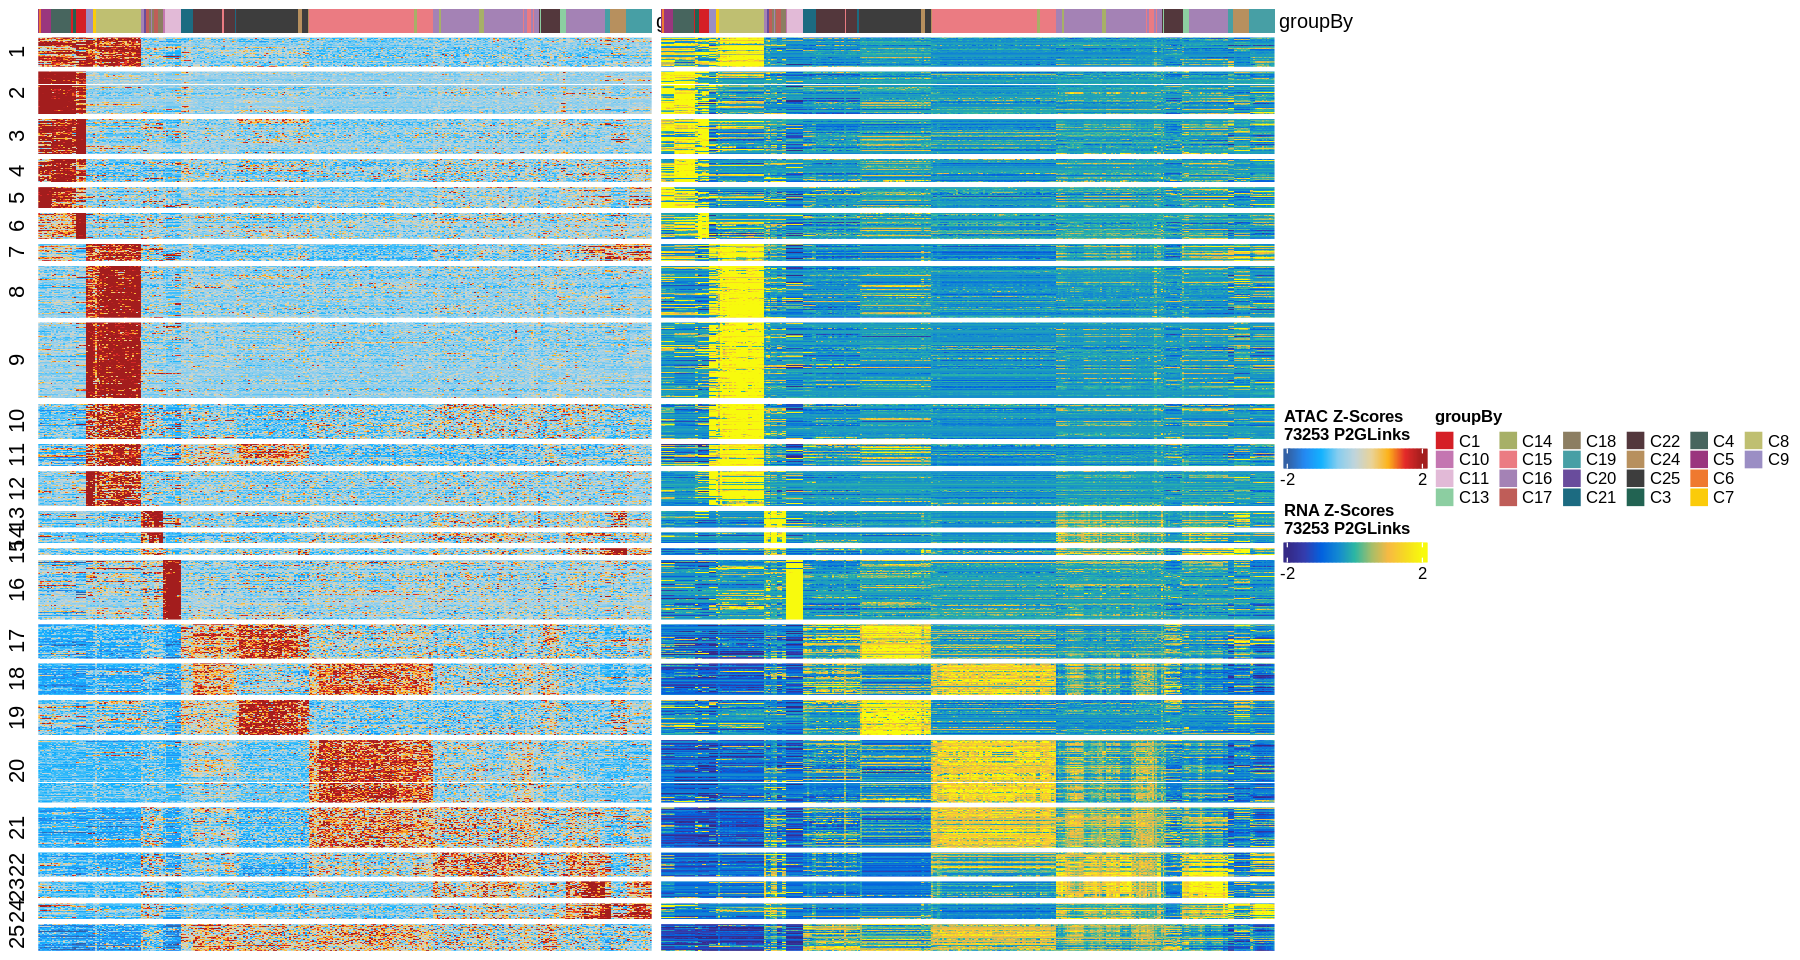

In [81]:
p

In [82]:
plotPDF(p, name = "Peak2Gene-Heatmap", width = 12, height = 9, ArchRProj = ArchRProject.filt, addDOC = FALSE)

Plotting ComplexHeatmap!



### Pairwise motif testing

#### YS erythroids vs other erythroids